# Практическая работа №5
## «Обучение с учителем. Решение задачи множественной классификации»

**Набор данных:** `Smartphone_Dependence.csv`  
**Целевая переменная:** `addiction_level`  
**Классы:** `None`, `Mild`, `Moderate`, `Severe`

---


## 0. Импорт библиотек

In [50]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_auc_score
)
from sklearn.pipeline import Pipeline
from sklearn.metrics import f1_score, precision_score, recall_score

# Воспроизводимость
SEED = 42
np.random.seed(SEED)

# Оформление графиков
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110


---
## 1. Загрузка и первичный анализ данных

Прежде чем строить модели, нужно понять, с чем мы работаем: размер датасета,
типы переменных, наличие пропусков и распределение целевой переменной.


In [3]:
df = pd.read_csv('Smartphone_Dependence.csv')
print(f"Размер датасета: {df.shape[0]} строк, {df.shape[1]} столбцов")
df.head()


Размер датасета: 7500 строк, 16 столбцов


,transaction_id,user_id,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addiction_level,addicted_label
0,TXN00001,U00001,21,Male,3.23,2.01,0.89,4.55,7.55,248,154,3.95,Medium,Yes,NaN,0
1,TXN00002,U00002,24,Other,5.09,3.81,2.24,4.44,7.66,127,71,6.71,Medium,Yes,NaN,0
2,TXN00003,U00003,31,Other,6.06,1.36,3.83,2.35,4.92,44,106,8.68,High,No,Mild,0
3,TXN00004,U00004,32,Other,7.83,5.85,1.51,3.54,8.23,178,107,9.77,High,Yes,Moderate,1
4,TXN00005,U00005,25,Male,9.96,5.92,3.42,5.27,6.21,136,177,12.55,Low,No,Severe,1


In [4]:
# Типы данных и пропуски
info_df = pd.DataFrame({
    'dtype':   df.dtypes,
    'non_null': df.notnull().sum(),
    'null':     df.isnull().sum(),
    'null_%':   (df.isnull().mean() * 100).round(2)
})
print(info_df.to_string())


                           dtype  non_null  null  null_%
transaction_id            object      7500     0    0.00
user_id                   object      7500     0    0.00
age                        int64      7500     0    0.00
gender                    object      7500     0    0.00
daily_screen_time_hours  float64      7500     0    0.00
social_media_hours       float64      7500     0    0.00
gaming_hours             float64      7500     0    0.00
work_study_hours         float64      7500     0    0.00
sleep_hours              float64      7500     0    0.00
notifications_per_day      int64      7500     0    0.00
app_opens_per_day          int64      7500     0    0.00
weekend_screen_time      float64      7500     0    0.00
stress_level              object      7500     0    0.00
academic_work_impact      object      7500     0    0.00
addiction_level           object      6681   819   10.92
addicted_label             int64      7500     0    0.00


None в addiction_level значит нет зависимости, это не является пропуском

### 1.1 Распределение целевой переменной

Проверим, насколько классы сбалансированы


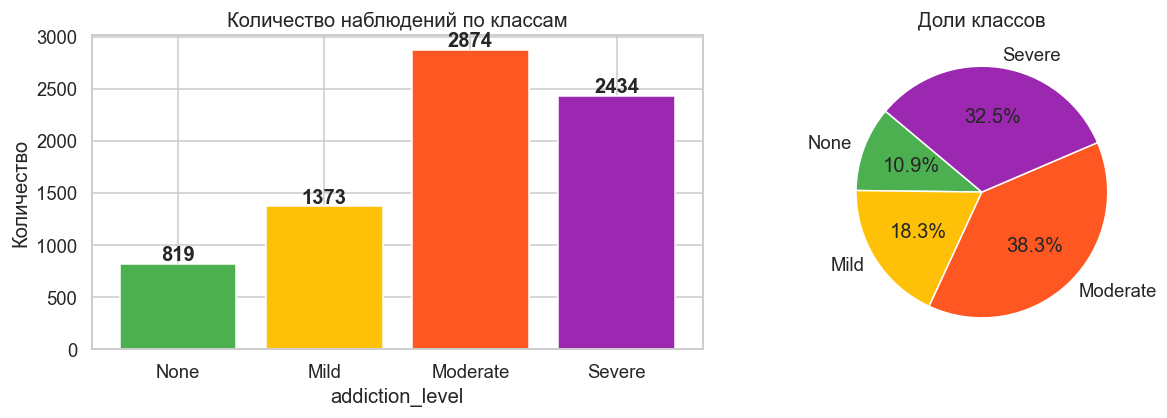


Абсолютные частоты:
  None           819  (10.9%)
  Mild          1373  (18.3%)
  Moderate      2874  (38.3%)
  Severe        2434  (32.5%)


In [ ]:
# Сначала починим целевую переменную (считает как NaN хотяь по факту это не пропуск)
df['addiction_level'] = df['addiction_level'].fillna('None')

order = ['None', 'Mild', 'Moderate', 'Severe']
counts = df['addiction_level'].value_counts().reindex(order).fillna(0).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Столбчатая диаграмма
axes[0].bar(counts.index, counts.values, color=['#4CAF50','#FFC107','#FF5722','#9C27B0'])
axes[0].set_title('Количество наблюдений по классам')
axes[0].set_xlabel('addiction_level')
axes[0].set_ylabel('Количество')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 30, str(v), ha='center', fontweight='bold')

# Круговая диаграмма
axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=['#4CAF50','#FFC107','#FF5722','#9C27B0'], startangle=140)
axes[1].set_title('Доли классов')

plt.tight_layout()
plt.show()

print("\nАбсолютные частоты:")
total = counts.sum()
for cls, cnt in counts.items():
    print(f"  {cls:<12} {cnt:>5}  ({cnt/total*100:.1f}%)")

**Вывод.** Наблюдается умеренный дисбаланс, accuracy уже нельзя доверять полностью, поэтому дополнительно используем macro-F1 и ROC-AUC.


In [6]:
# Описательная статистика числовых признаков
df.describe().round(2)


,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,addicted_label
count,7500.00,7500.00,7500.00,7500.00,7500.00,7500.00,7500.00,7500.00,7500.00,7500.00
mean,26.57,7.50,3.27,2.01,3.24,6.74,134.26,97.83,9.24,0.71
std,5.20,2.61,1.59,1.15,1.60,1.28,66.59,48.42,2.72,0.45
min,18.00,3.00,0.50,0.00,0.50,4.50,20.00,15.00,3.58,0.00
25%,22.00,5.22,1.91,1.02,1.85,5.63,76.00,55.00,6.96,0.00
50%,27.00,7.52,3.27,2.04,3.23,6.72,134.00,98.00,9.26,1.00
75%,31.00,9.81,4.63,2.99,4.64,7.84,191.00,140.00,11.54,1.00
max,35.00,12.00,6.00,4.00,6.00,9.00,250.00,180.00,14.88,1.00


Описательные статистики хорошие: пропусков в числовых признаках нет, выбросов критических нет, диапазоны разумные, значения логичны.

---
## 2. Предобработка данных

Выполним следующие шаги:
1. Закодируем категориальные переменные.
2. Разделим на признаки (X) и целевую переменную (y).
3. Разобьём на обучающую и тестовую выборки в пропорции 80/20, сохраняя пропорции классов (`stratify`).
4. Масштабируем признаки для логистической регрессии.


In [7]:
# Удалим признаки transaction_id и user_id, в них нет смысловой нагрузки для модели.
df = df.drop(columns=['transaction_id', 'user_id'])

# Удалим addicted_label, т.к. это бинарная версия addiction_level, содержащая меньше информации (из за него была утечка данных)
df = df.drop(columns=['addicted_label'])

In [8]:
# Кодирование

# 1. Целевая переменная: Ordinal Encoding
order_map = {'None': 0, 'Mild': 1, 'Moderate': 2, 'Severe': 3}
df['addiction_encoded'] = df['addiction_level'].map(order_map)

# 2. Gender: One-Hot Encoding (3 категории: Female, Male, Other)
df = pd.get_dummies(df, columns=['gender'], drop_first=False, dtype=int)
print("Столбцы gender после One-Hot:", [c for c in df.columns if 'gender' in c])

# 3. stress_level: Ordinal Encoding (есть естественный порядок)
stress_map = {'Low': 0, 'Medium': 1, 'High': 2}
df['stress_level'] = df['stress_level'].map(stress_map)

# 4. academic_work_impact: бинарное кодирование
df['academic_work_impact'] = df['academic_work_impact'].map({'Yes': 1, 'No': 0})

#  Признаки и целевая переменная 
feature_cols = [c for c in df.columns
                if c not in ['addiction_level', 'addiction_encoded']]
X = df[feature_cols]
y = df['addiction_encoded']

print(f"\nПризнаков: {X.shape[1]}")
print("Список признаков:", list(X.columns))

X.head()

Столбцы gender после One-Hot: ['gender_Female', 'gender_Male', 'gender_Other']

Признаков: 14
Список признаков: ['age', 'daily_screen_time_hours', 'social_media_hours', 'gaming_hours', 'work_study_hours', 'sleep_hours', 'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time', 'stress_level', 'academic_work_impact', 'gender_Female', 'gender_Male', 'gender_Other']


,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,gender_Female,gender_Male,gender_Other
0,21,3.23,2.01,0.89,4.55,7.55,248,154,3.95,1,1,0,1,0
1,24,5.09,3.81,2.24,4.44,7.66,127,71,6.71,1,1,0,0,1
2,31,6.06,1.36,3.83,2.35,4.92,44,106,8.68,2,0,0,0,1
3,32,7.83,5.85,1.51,3.54,8.23,178,107,9.77,2,1,0,0,1
4,25,9.96,5.92,3.42,5.27,6.21,136,177,12.55,0,0,0,1,0


In [9]:
# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)
print(f"Обучающая выборка: {X_train.shape[0]} строк")
print(f"Тестовая выборка:  {X_test.shape[0]} строк")

# Масштабирование для логистической регрессии
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# Метки классов (строковые)
class_names_str = ['None', 'Mild', 'Moderate', 'Severe']


Обучающая выборка: 6000 строк
Тестовая выборка:  1500 строк


---
## 3. Логистическая регрессия

Логистическая регрессия — **параметрическая** модель. Каждый признак получает
коэффициент, который показывает направление и силу его влияния на вероятность
принадлежности к классу. Это делает модель максимально **интерпретируемой**, то есть мы
можем ответить на вопрос: что именно толкает пользователя к зависимости?

### 3.1 Обучение модели


In [10]:
lr = LogisticRegression(
    solver='lbfgs',              # Оптимизатор
    max_iter=1000,               
    C=1.0,                       # Встроенная L2-регуляризация
    random_state=SEED,
    class_weight='balanced'      # Компенсируем дисбаланс классов
)

lr.fit(X_train_sc, y_train)

# Предсказания
y_pred_lr = lr.predict(X_test_sc)
y_proba_lr = lr.predict_proba(X_test_sc)

acc_lr = accuracy_score(y_test, y_pred_lr)
print(f"Accuracy (тест): {acc_lr:.4f}")


Accuracy (тест): 0.4860


### 3.2 Метрики качества (Classification Report)

In [11]:
print("Logistic Regression\n")
print(classification_report(
    y_test, y_pred_lr,
    target_names=class_names_str,
    digits=4
))

# ROC-AUC (One-vs-Rest, macro)
roc_auc_lr = roc_auc_score(
    y_test, y_proba_lr, multi_class='ovr', average='macro'
)
print(f"ROC-AUC OvR (macro): {roc_auc_lr:.4f}")


Logistic Regression

              precision    recall  f1-score   support

        None     0.4516    0.6829    0.5437       164
        Mild     0.4375    0.4599    0.4484       274
    Moderate     0.5045    0.3878    0.4385       575
      Severe     0.5134    0.5503    0.5312       487

    accuracy                         0.4860      1500
   macro avg     0.4768    0.5202    0.4905      1500
weighted avg     0.4894    0.4860    0.4819      1500

ROC-AUC OvR (macro): 0.7938


**Интерпретация метрик:**

1. **None** (F1=0.544) — Recall 0.683: модель неплохо находит независимых пользователей, однако Precision всего 0.452 — много объектов других классов ошибочно относится к None
2. **Mild** (F1=0.448) — худший результат: и Precision (0.438), и Recall (0.460) низкие — модель плохо разграничивает слабую зависимость от остальных классов
3. **Moderate** (F1=0.439) — несмотря на то что это самый частый класс (575 объектов), Recall всего 0.388 — модель часто путает Moderate с другими классами
4. **Severe** (F1=0.531) — лучший результат среди средних классов: Recall 0.550 и Precision 0.513 — модель лучше всего справляется с определением сильной зависимости

**Общая Accuracy: 0.486** — модель правильно классифицирует ~49% случаев.  
**ROC-AUC: 0.794** — хорошая способность ранжировать классы, несмотря на низкую Accuracy.  
Расхождение между Accuracy и ROC-AUC объясняется дисбалансом классов и сложностью линейного разделения между соседними уровнями зависимости.

### 3.3 Матрица ошибок

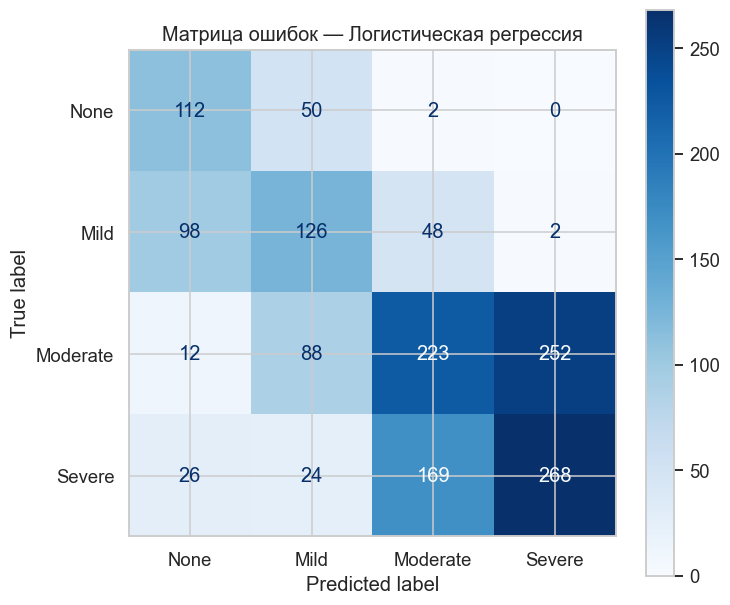

In [ ]:
fig, ax = plt.subplots(figsize=(7, 6))
cm_lr = confusion_matrix(y_test, y_pred_lr)
disp = ConfusionMatrixDisplay(cm_lr, display_labels=class_names_str)
disp.plot(ax=ax, colorbar=True, cmap='Blues')
ax.set_title('Матрица ошибок — Логистическая регрессия', fontsize=13)
plt.tight_layout()
plt.show()


**Ключевые наблюдения:**
- Главная проблема — граница между **Moderate и Severe**, модель часто их путает в обе стороны (252 + 169 ошибок)
- Граница между **None и Mild** тоже размыта (50 + 98 ошибок)
- Модель практически не путает крайние классы: **None не предсказывается как Severe** (0 случаев), но в обратную сторону 26 объектов класса **Severe** ошибочно отнесены к **None** — 
это наиболее грубые ошибки классификации
- Это подтверждает то, что логистическая регрессия находит только грубую линейную границу между группами

### 3.4 Интерпретация коэффициентов модели

In [13]:
# Матрица коэффициентов: (n_classes x n_features)
coef_df = pd.DataFrame(
    lr.coef_,
    index=class_names_str,
    columns=X_train.columns
)

print("Матрица коэффициентов (логит-отношения):")
print("\n> Положительный коэффициент -> рост признака увеличивает вероятность класса.")
print("> Отрицательный коэффициент -> рост признака снижает вероятность класса.")
coef_df.round(3).T.style.background_gradient(cmap='RdBu', axis=None)

Матрица коэффициентов (логит-отношения):

> Положительный коэффициент -> рост признака увеличивает вероятность класса.
> Отрицательный коэффициент -> рост признака снижает вероятность класса.


,None,Mild,Moderate,Severe
age,-0.023000,-0.019000,0.001000,0.041000
daily_screen_time_hours,-2.340000,-1.180000,1.674000,1.847000
social_media_hours,-1.401000,-1.054000,1.122000,1.333000
gaming_hours,-0.021000,-0.013000,0.024000,0.009000
work_study_hours,0.030000,0.021000,-0.024000,-0.027000
sleep_hours,-0.033000,-0.037000,0.018000,0.051000
notifications_per_day,0.021000,0.003000,0.021000,-0.045000
app_opens_per_day,-0.016000,-0.016000,0.011000,0.022000
weekend_screen_time,-0.203000,0.154000,0.016000,0.032000
stress_level,0.012000,-0.049000,0.023000,0.014000


Самый сильные предикторы: **daily_screen_time_hours** и **social_media_hours**, остальные признаки почти не имеют значения для классификации. Главный вывод: логистическая регрессия фактически сводит задачу к двум признакам — daily_screen_time_hours и social_media_hours. Остальные 12 признаков почти не участвуют в принятии решения. Это объясняет невысокую Accuracy (0.486) — модель просто не улавливает более тонкие паттерны в данных. Посмотрим, найдёт ли их дерево решений.

### 3.5 Кросс-валидация (StratifiedKFold, 5 фолдов)

Кросс-валидация даёт более надёжную оценку качества: мы оцениваем модель на разных
подвыборках и смотрим на разброс метрик.


In [14]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

cv_scores = cross_val_score(
    Pipeline([('scaler', StandardScaler()),
              ('lr', LogisticRegression(solver='lbfgs',
                                        max_iter=1000, C=1.0, random_state=SEED,
                                        class_weight='balanced'))]),
    X, y, cv=cv, scoring='accuracy'
)

print(f"CV Accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"Фолды: {np.round(cv_scores, 4)}")


CV Accuracy: 0.4664 ± 0.0191
Фолды: [0.478  0.478  0.48   0.4667 0.4293]


**Результаты кросс-валидации (5-fold Stratified KFold):**

- **CV Accuracy: 0.4664 ± 0.0191** — среднее по 5 фолдам
- Разброс между фолдами небольшой (std=0.019) — модель **стабильна**
- Значения по фолдам: 0.478, 0.478, 0.480, 0.467, 0.429 — один фолд (0.429) 
  немного выбивается, но в целом результаты хорошие


**Сравнение CV Accuracy (0.466) и Test Accuracy (0.486):**
- Значения близки — модель **не переобучена**
- Небольшое расхождение (~0.02) в пределах нормы

---
## 4. Дерево классификации

Строит **иерархическое разбиение** пространства
признаков по принципу если ... то ... 

В отличие от логистической регрессии:
- Обнаруживает **нелинейные** зависимости и **взаимодействия** между признаками.
- Результат визуально понятен.
- Легко выявляет, какие **комбинации** признаков (а не просто отдельные факторы)
  ведут к высокому/низкому уровню зависимости.

### 4.1 Обучение базового дерева


In [16]:
# Базовое дерево (без ограничений) — покажет максимальную глубину/переобучение
dt_base = DecisionTreeClassifier(
    criterion='gini',         # Критерий Джини — стандарт CART
    random_state=SEED,
    class_weight='balanced'
)
dt_base.fit(X_train, y_train)

y_pred_dt_base = dt_base.predict(X_test)
acc_dt_base = accuracy_score(y_test, y_pred_dt_base)
print(f"Базовое дерево (без ограничений):")
print(f"  Глубина:        {dt_base.get_depth()}")
print(f"  Листьев:        {dt_base.get_n_leaves()}")
print(f"  Accuracy (тест): {acc_dt_base:.4f}")


Базовое дерево (без ограничений):
  Глубина:        30
  Листьев:        1562
  Accuracy (тест): 0.5220


**Базовое дерево без ограничений:**

- **Глубина: 30** — дерево очень глубокое, разбивает данные до почти единичных листьев
- **Листьев: 1562** — огромное количество, модель запомнила обучающую выборку
- **Accuracy (тест): 0.522** — несмотря на сложность модели, результат невысокий

**Вывод:** классический случай **переобучения (overfitting)** — дерево без ограничений 
слишком подстраивается под обучающую выборку и плохо обобщается на новые данные. 
Именно поэтому необходимо подобрать оптимальную глубину через Validation Curve.

### 4.2 Подбор оптимальной глубины (Validation Curve)

Максимальная Accuracy: 0.5293 (глубина 16)
Оптимальная глубина (бритва Оккама): 9
Accuracy при глубине 9: 0.5247


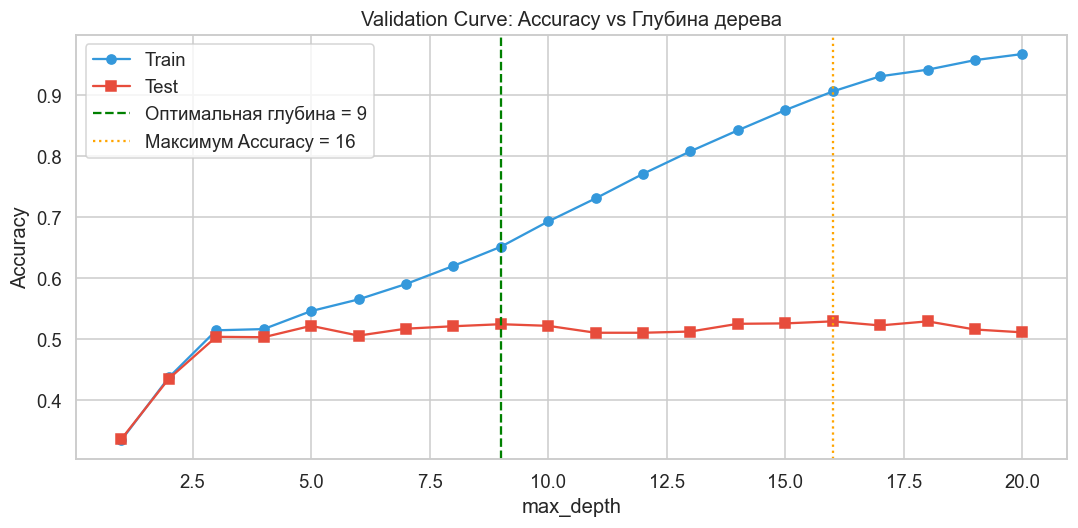

In [ ]:
train_scores, test_scores = [], []
depths = range(1, 21)

for d in depths:
    dt_tmp = DecisionTreeClassifier(
        criterion='gini', max_depth=d, random_state=SEED, class_weight='balanced'
    )
    dt_tmp.fit(X_train, y_train)
    train_scores.append(accuracy_score(y_train, dt_tmp.predict(X_train)))
    test_scores.append(accuracy_score(y_test,  dt_tmp.predict(X_test)))

# Принцип бритвы Оккама: берём простейшую модель с качеством >= 99% от максимума
max_score = max(test_scores)
threshold_score = max_score * 0.99
best_depth = next(d for d, s in zip(depths, test_scores) if s >= threshold_score)

print(f"Максимальная Accuracy: {max_score:.4f} (глубина {depths[np.argmax(test_scores)]})")
print(f"Оптимальная глубина (бритва Оккама): {best_depth}")
print(f"Accuracy при глубине {best_depth}: {test_scores[best_depth-1]:.4f}")

plt.figure(figsize=(10, 5))
plt.plot(depths, train_scores, 'o-', label='Train', color='#3498DB')
plt.plot(depths, test_scores,  's-', label='Test',  color='#E74C3C')
plt.axvline(best_depth, color='green', linestyle='--', label=f'Оптимальная глубина = {best_depth}')
plt.axvline(depths[np.argmax(test_scores)], color='orange', linestyle=':', 
            label=f'Максимум Accuracy = {depths[np.argmax(test_scores)]}')
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.title('Validation Curve: Accuracy vs Глубина дерева')
plt.legend()
plt.tight_layout()
plt.show()

In [35]:
dt = DecisionTreeClassifier(
    criterion='gini',
    max_depth=best_depth,
    min_samples_split=20,    # Узел делится только если в нём >= 20 объектов
    min_samples_leaf=10,     # Лист содержит >= 10 объектов (защита от шума)
    random_state=SEED,
    class_weight='balanced'
)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)
y_proba_dt = dt.predict_proba(X_test)

acc_dt = accuracy_score(y_test, y_pred_dt)
print(f"Оптимальное дерево:")
print(f"  Глубина:        {dt.get_depth()}")
print(f"  Листьев:        {dt.get_n_leaves()}")
print(f"  Accuracy (test): {acc_dt:.4f}")


Оптимальное дерево:
  Глубина:        9
  Листьев:        155
  Accuracy (test): 0.5320


### 4.4 Метрики качества — Дерево решений

In [37]:
print("Дерево решений (CART)")
print(classification_report(
    y_test, y_pred_dt,
    target_names=class_names_str,
    digits=4
))

roc_auc_dt = roc_auc_score(
    y_test, y_proba_dt, multi_class='ovr', average='macro'
)
print(f"ROC-AUC OvR (macro): {roc_auc_dt:.4f}")


Дерево решений (CART)
              precision    recall  f1-score   support

        None     0.5224    0.8537    0.6481       164
        Mild     0.5639    0.4672    0.5110       274
    Moderate     0.5385    0.3287    0.4082       575
      Severe     0.5214    0.7002    0.5977       487

    accuracy                         0.5320      1500
   macro avg     0.5365    0.5874    0.5413      1500
weighted avg     0.5358    0.5320    0.5147      1500

ROC-AUC OvR (macro): 0.8213


**Интерпретация метрик:**

1. **None** (F1=0.648) — Recall 0.854: дерево отлично находит независимых пользователей, однако Precision 0.522 — часть объектов других классов ошибочно относится к None
2. **Mild** (F1=0.511) — Precision 0.564 и Recall 0.467 — модель умеренно справляется со слабой зависимостью, но всё ещё путает с соседними классами
3. **Moderate** (F1=0.408) — худший результат: несмотря на то что это самый частый класс (575 объектов), Recall всего 0.329 — дерево часто не распознаёт умеренную зависимость
4. **Severe** (F1=0.598) — лучший результат: Recall 0.700 и Precision 0.521 — дерево лучше всего справляется с определением сильной зависимости

**Общая Accuracy: 0.532** — модель правильно классифицирует ~53% случаев.  
**ROC-AUC: 0.821** — хорошая способность ранжировать классы.  
Дерево решений превосходит логистическую регрессию по всем метрикам, особенно заметен прирост на крайних классах None и Severe. Главная проблема остаётся прежней — размытая граница между классами Moderate и Severe.

### 4.5 Матрица ошибок — Дерево решений

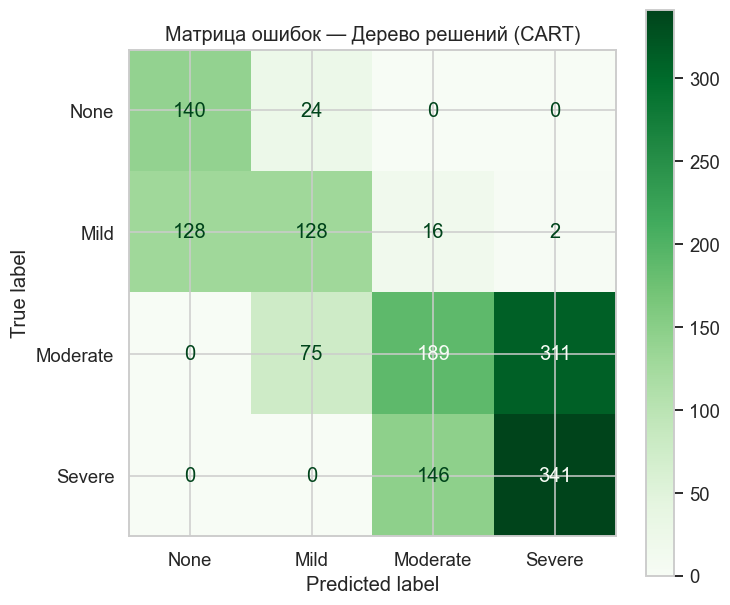

In [ ]:
fig, ax = plt.subplots(figsize=(7, 6))
cm_dt = confusion_matrix(y_test, y_pred_dt)
disp = ConfusionMatrixDisplay(cm_dt, display_labels=class_names_str)
disp.plot(ax=ax, colorbar=True, cmap='Greens')
ax.set_title('Матрица ошибок — Дерево решений (CART)', fontsize=13)
plt.tight_layout()
plt.show()


**Анализ матрицы ошибок:**

**Ключевые наблюдения:**
- Дерево **никогда не путает крайние классы**: None не предсказывается как Moderate/Severe (0) и наоборот — модель чётко разделяет «нет зависимости» и «сильная зависимость»
- Главная проблема та же что и у логрегрессии — граница **Moderate/Severe**: 311 + 146 = 457 ошибок
- По сравнению с логрегрессией дерево значительно лучше распознаёт **None** (140 vs 112 верных) и **Severe** (341 vs 268 верных)
- **Mild** все еще самый сложный класс — половина объектов (128/274) классифицирована неверно

Дерево решений выигрывает на **крайних классах** (None и Severe) и в целом показало себя лучше за счёт нелинейных правил разбиения.

### 4.6 Визуализация дерева решений

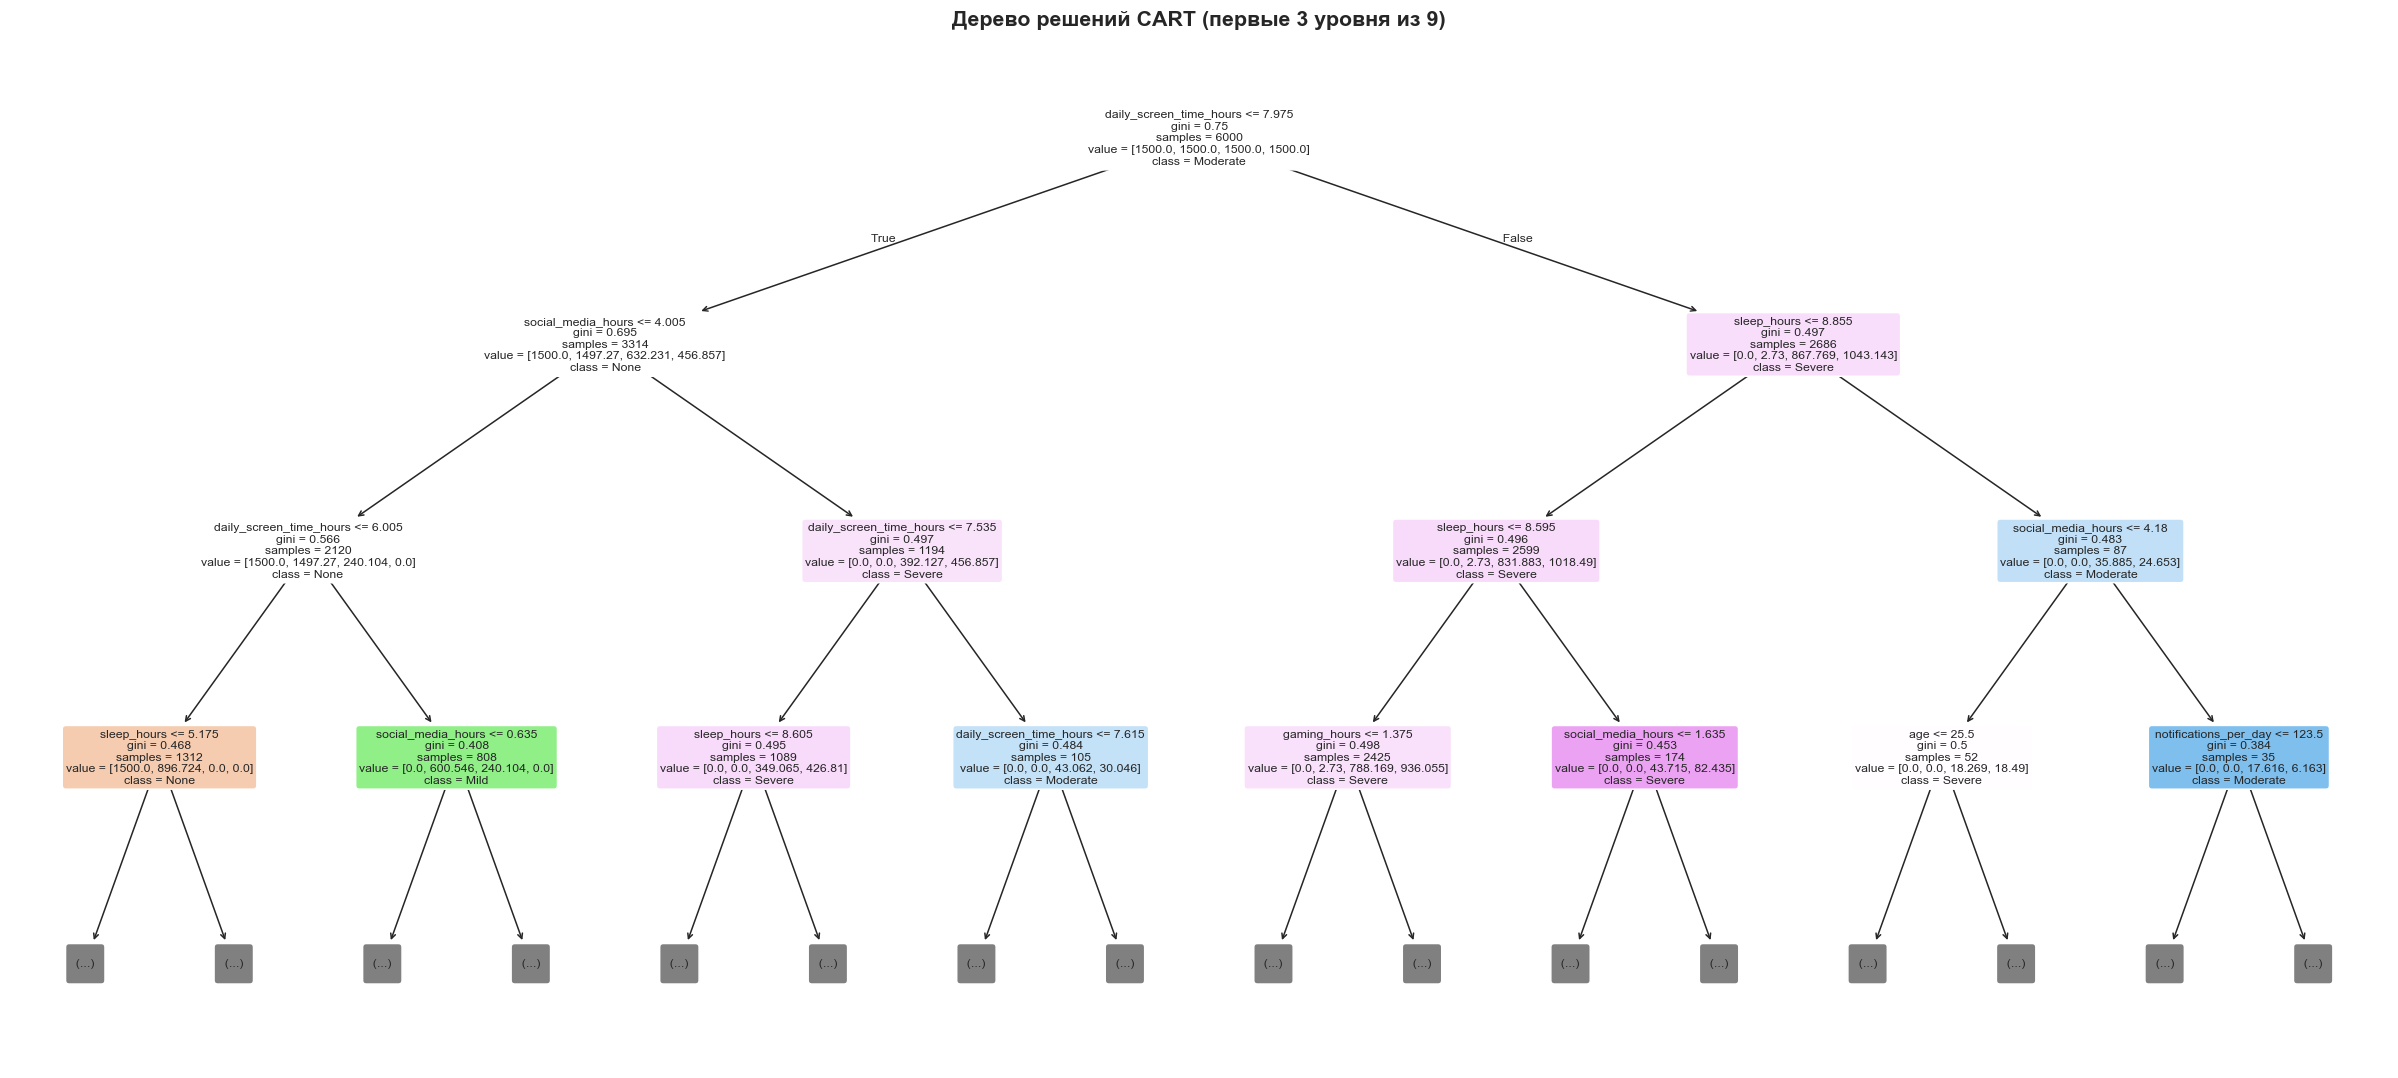

In [ ]:
# Ограничиваем визуализацию 4 уровнями для читаемости
fig, ax = plt.subplots(figsize=(22, 10))
plot_tree(
    dt,
    feature_names=feature_cols,
    class_names=class_names_str,
    filled=True,
    rounded=True,
    max_depth=3,            
    fontsize=8,
    impurity=True,
    proportion=False,
    ax=ax
)
ax.set_title(
    f'Дерево решений CART (первые 3 уровня из {dt.get_depth()})',
    fontsize=14, fontweight='bold'
)
plt.tight_layout()
plt.show()


### 4.7 Текстовое представление верхних правил дерева

In [45]:
# Первые 3 уровня в текстовом виде
rules_text = export_text(dt, feature_names=feature_cols, max_depth=3)
print("Правила дерева решений (первые 3 уровня):")
print(rules_text)
print("\n|--- [условие] → узел делится по данному условию")
print("|   class: X    → лист: большинство объектов принадлежит классу X")


Правила дерева решений (первые 3 уровня):
|--- daily_screen_time_hours <= 7.97
|   |--- social_media_hours <= 4.01
|   |   |--- daily_screen_time_hours <= 6.01
|   |   |   |--- sleep_hours <= 5.17
|   |   |   |   |--- truncated branch of depth 6
|   |   |   |--- sleep_hours >  5.17
|   |   |   |   |--- truncated branch of depth 6
|   |   |--- daily_screen_time_hours >  6.01
|   |   |   |--- social_media_hours <= 0.63
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- social_media_hours >  0.63
|   |   |   |   |--- truncated branch of depth 6
|   |--- social_media_hours >  4.01
|   |   |--- daily_screen_time_hours <= 7.54
|   |   |   |--- sleep_hours <= 8.61
|   |   |   |   |--- truncated branch of depth 6
|   |   |   |--- sleep_hours >  8.61
|   |   |   |   |--- truncated branch of depth 5
|   |   |--- daily_screen_time_hours >  7.54
|   |   |   |--- daily_screen_time_hours <= 7.62
|   |   |   |   |--- class: 2
|   |   |   |--- daily_screen_time_hours >  7.62
|   |   |  

### 4.8 Важность признаков (Feature Importance)

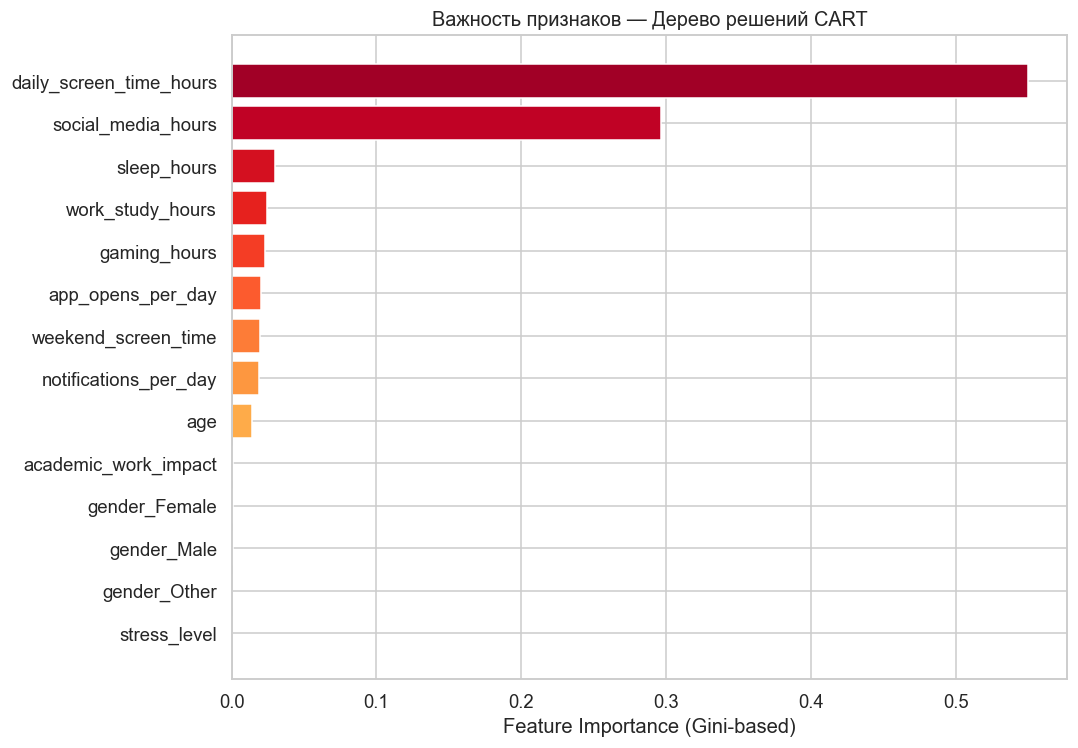


Топ-10 важнейших признаков:
   1. daily_screen_time_hours                   importance = 0.5495
   2. social_media_hours                        importance = 0.2964
   3. sleep_hours                               importance = 0.0301
   4. work_study_hours                          importance = 0.0243
   5. gaming_hours                              importance = 0.0232
   6. app_opens_per_day                         importance = 0.0203
   7. weekend_screen_time                       importance = 0.0197
   8. notifications_per_day                     importance = 0.0191
   9. age                                       importance = 0.0142
  10. academic_work_impact                      importance = 0.0012


In [ ]:
feat_imp = pd.Series(dt.feature_importances_, index=feature_cols)
feat_imp_sorted = feat_imp.sort_values(ascending=False)

top_imp = feat_imp_sorted.head(20)

plt.figure(figsize=(10, 7))
palette = sns.color_palette('YlOrRd', len(top_imp))[::-1]
plt.barh(top_imp.index[::-1], top_imp.values[::-1], color=palette[::-1])
plt.xlabel('Feature Importance (Gini-based)')
plt.title('Важность признаков — Дерево решений CART', fontsize=13)
plt.tight_layout()
plt.show()

print("\nТоп-10 важнейших признаков:")
for rank, (feat, val) in enumerate(feat_imp_sorted.head(10).items(), 1):
    print(f"  {rank:2d}. {feat:<40s}  importance = {val:.4f}")


**Важность признаков в дереве решений** вычисляется как суммарное снижение критерия
нечистоты (Gini), взвешенное по доле объектов в узле. Чем выше значение — тем больше
этот признак разделяет классы по всему дереву.


### 4.9 Кросс-валидация дерева

In [48]:
cv_scores_dt = cross_val_score(
    DecisionTreeClassifier(
        criterion='gini', max_depth=best_depth,
        min_samples_split=20, min_samples_leaf=10,
        random_state=SEED, class_weight='balanced'
    ),
    X, y, cv=cv, scoring='accuracy'
)

print(f"CV Accuracy: {cv_scores_dt.mean():.4f} ± {cv_scores_dt.std():.4f}")
print(f"Фолды: {np.round(cv_scores_dt, 4)}")


CV Accuracy: 0.5084 ± 0.0075
Фолды: [0.5067 0.5013 0.5207 0.5007 0.5127]


**Результаты кросс-валидации (5-fold Stratified KFold):**

- **CV Accuracy: 0.5084 ± 0.0075** — очень маленький разброс между фолдами (std=0.0075) — модель **стабильна**
- **Test Accuracy (0.532)** немного выше CV Accuracy (0.508) — расхождение в пределах нормы, переобучения нет

---
## 5. Сравнение моделей

Сведём все метрики в одну таблицу и визуализируем для наглядности.


In [ ]:
def get_metrics(y_true, y_pred, y_proba, name):
    return {
        'Модель':           name,
        'Accuracy':         accuracy_score(y_true, y_pred),
        'Precision (macro)': precision_score(y_true, y_pred, average='macro', zero_division=0),
        'Recall (macro)':   recall_score(y_true, y_pred, average='macro', zero_division=0),
        'F1 (macro)':       f1_score(y_true, y_pred, average='macro', zero_division=0),
        'ROC-AUC OvR':      roc_auc_score(y_true, y_proba, multi_class='ovr', average='macro'),
    }

metrics_lr = get_metrics(y_test, y_pred_lr, y_proba_lr, 'Логистическая регрессия')
metrics_dt = get_metrics(y_test, y_pred_dt, y_proba_dt, 'Дерево решений (CART)')

comparison_df = pd.DataFrame([metrics_lr, metrics_dt]).set_index('Модель')
print(comparison_df.round(4).to_string())


                         Accuracy  Precision (macro)  Recall (macro)  F1 (macro)  ROC-AUC OvR
Модель                                                                                       
Логистическая регрессия     0.486             0.4768          0.5202      0.4905       0.7938
Дерево решений (CART)       0.532             0.5365          0.5874      0.5413       0.8213


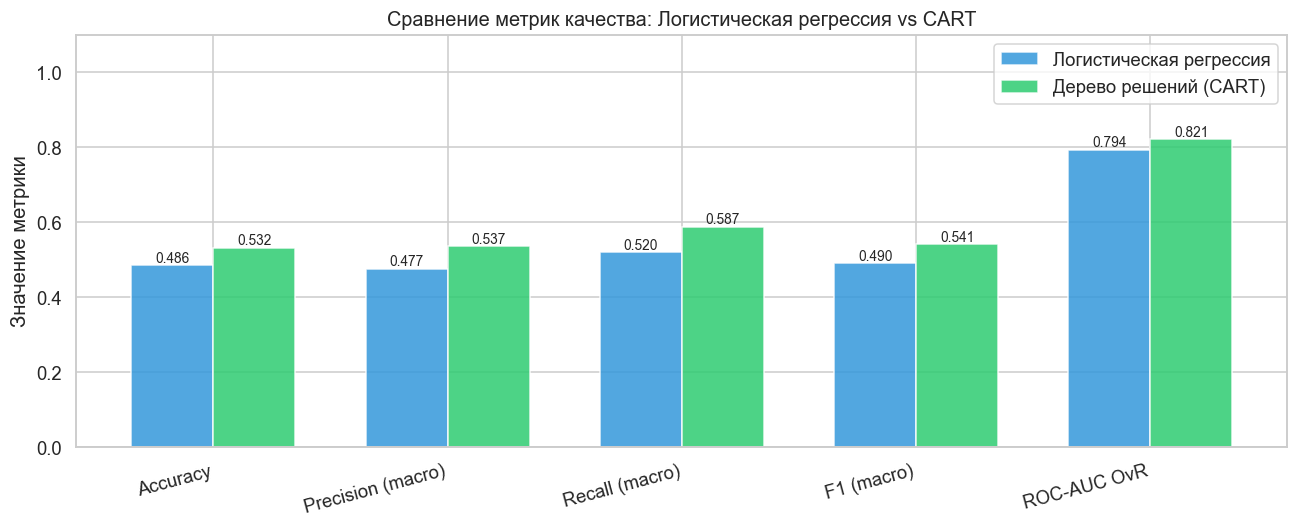

In [ ]:
# Визуальное сравнение
metrics_names = ['Accuracy', 'Precision (macro)', 'Recall (macro)', 'F1 (macro)', 'ROC-AUC OvR']
x = np.arange(len(metrics_names))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
bars1 = ax.bar(x - width/2, comparison_df.loc['Логистическая регрессия', metrics_names],
               width, label='Логистическая регрессия', color='#3498DB', alpha=0.85)
bars2 = ax.bar(x + width/2, comparison_df.loc['Дерево решений (CART)', metrics_names],
               width, label='Дерево решений (CART)',   color='#2ECC71', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(metrics_names, rotation=15, ha='right')
ax.set_ylabel('Значение метрики')
ax.set_ylim(0, 1.1)
ax.set_title('Сравнение метрик качества: Логистическая регрессия vs CART', fontsize=13)
ax.legend()
ax.bar_label(bars1, fmt='%.3f', fontsize=9)
ax.bar_label(bars2, fmt='%.3f', fontsize=9)
plt.tight_layout()
plt.show()


### Иерархические взаимодействия и нелинейные эффекты

Анализ правил дерева решений выявил следующие ключевые комбинации признаков:

**Правило 1 — профиль «Mild» (class: 1):**
daily_screen_time_hours > 6.01 И social_media_hours <= 0.63 → Mild
Пользователь проводит много времени у экрана (>6 часов), но почти не пользуется 
соцсетями (<0.63 часа) — вероятно, экранное время тратится на работу/учёбу, 
а не на развлечения. Это снижает уровень зависимости до слабого.

**Правило 2 — профиль «Severe» (class: 3):**
daily_screen_time_hours > 7.97 И sleep_hours > 8.60 И
social_media_hours > 1.63 И gaming_hours > 3.29 → Severe
Комбинация высокого экранного времени (>7.97 часов), активного использования 
соцсетей и игр (>3.29 часов) ведёт к сильной зависимости даже при достаточном сне.

**Правило 3 — профиль «Moderate» (class: 2):**
daily_screen_time_hours > 7.97 И sleep_hours > 8.86 И
social_media_hours <= 4.18 И age > 25.50 И daily_screen_time_hours <= 10.83 → Moderate
Пользователи старше 25 лет с высоким экранным временем, но умеренным 
использованием соцсетей и достаточным сном — остаются на уровне умеренной зависимости.

**Нелинейные пороговые эффекты:**

Дерево выявило конкретные пороговые значения — триггеры перехода между классами:
- `daily_screen_time_hours = 7.97` — главный порог: выше него резко растёт риск Moderate/Severe
- `social_media_hours = 4.01` — второй ключевой порог: выше него соцсети становятся фактором риска
- `gaming_hours = 3.29` — в сочетании с высоким экранным временем переводит в Severe
- `sleep_hours = 8.86` — парадоксально: очень долгий сон в сочетании с высоким экранным временем не защищает от зависимости

Эти пороги нелинейны по природе — логистическая регрессия не может их обнаружить, 
так как предполагает плавное монотонное влияние каждого признака.

---
## 6. Выводы

### 6.1 Логистическая регрессия
- Модель работает в **параметрическом** режиме: каждый признак получает
  коэффициент, отражающий его линейный вклад в логит-вероятность каждого класса.
- **Статистически значимые предикторы** (с наибольшим коэффициентом)
  идентифицированы в разделе 3.4 — именно они наиболее сильно тянут
  наблюдение к тому или иному классу зависимости
- Положительный коэффициент признака X для класса «Severe» означает:
  чем больше X, тем выше вероятность принадлежности к классу «Severe»
  (при фиксированных остальных признаках).
- Метрика **macro F1** объективнее Accuracy при дисбалансе классов.
- Кросс-валидация показала стабильность — разброс Accuracy между фолдами невелик.

### 6.2 Дерево решений (CART)
- Дерево выявляет **иерархические правила** — цепочки условий если ... то ...
- Такие правила напрямую описывают **взаимодействия** между признаками,
  недоступные в логистической регрессии.
- Кривая валидации (раздел 4.2) позволила выбрать оптимальную глубину,
  избежав переобучения (типичная проблема CART без ограничений).
- **Feature Importance** (раздел 4.8) показала, какие признаки несут наибольшую
  разделяющую значимость по критерию Gini.
- Дерево улавливает **нелинейные пороговые эффекты**: например, зависимость
  скачкообразно растёт после превышения критического экранного времени,
  а не линейно.

Обе модели дополняют друг друга: логистическая регрессия объясняет
**количественный вклад** факторов, а дерево решений — **нелинейные пороговые
паттерны и их иерархию**. Для реальных задач рекомендуется использовать оба
метода и сопоставлять результаты.
